In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

import torch
import torch.nn as nn

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
minst = datasets.fetch_openml('mnist_784')

In [4]:
X = minst['data'].values # (70000, 784)
# normalize it very important
X = (X - X.min()) / X.max()
y = np.array(minst['target'].values) # (70000, )

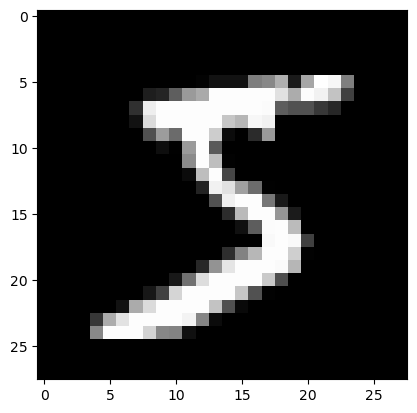

In [5]:
plt.imshow(X[0].reshape(28, 28), cmap="gray")

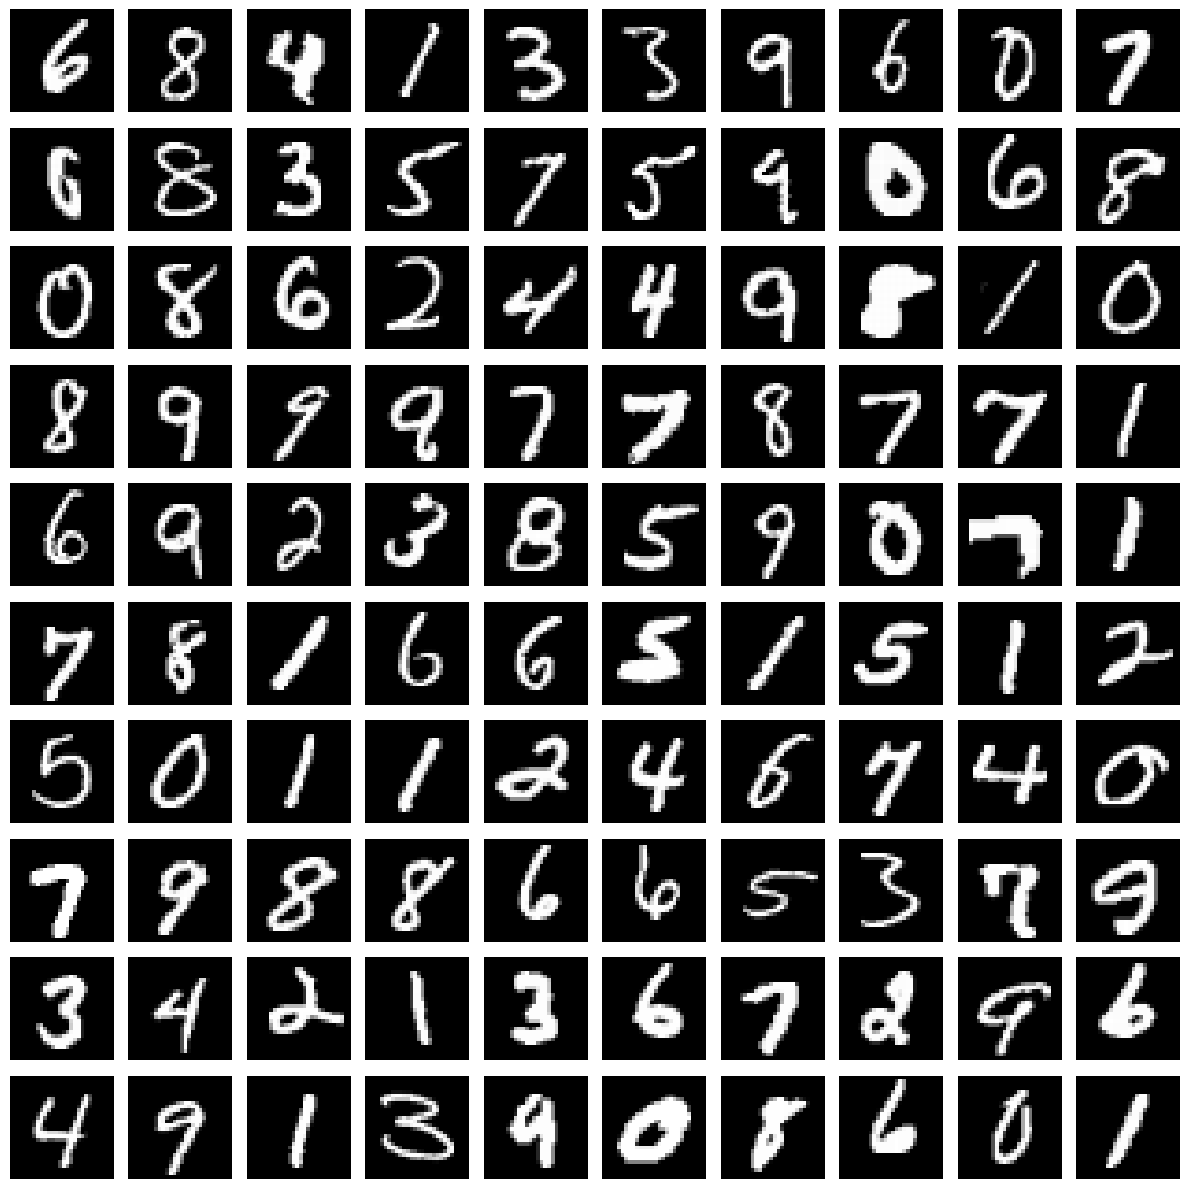

In [6]:
random_indices = np.random.choice(len(X), 100, replace=False)
fig, axes = plt.subplots(10, 10, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    # Reshape the flattened 1D array to 28x28 and plot it
    ax.imshow(X[random_indices[i]].reshape(28, 28), cmap='gray')
    ax.axis('off') # Hide axes for a cleaner look
plt.tight_layout()
plt.show()

# Prepare Datasets

In [ ]:
from sklearn.model_selection import test_test_split
X_test, X_test, y_test, y_test = test_test_split(X, y, test_size=0.2, stratify=y)

In [28]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class MINSTDataset(Dataset):
    """ Takes Tensor of data between [0, 1] and transfer it to [-1, 1] by using Norrmalize"""
    def __init__(self, numpy_arr, apply_normalization:bool = True):
        self.data = torch.tensor(numpy_arr)
        self.normalize = transforms.Normalize([0.5], [0.5])
        self.apply_normalization = apply_normalization
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        x = self.data[idx].view(1, 28, 28).float()

        if self.apply_normalization:
            return self.normalize(x)
        else:
            return x


In [29]:
minst_dataset_train = MINSTDataset(X_train)
minst_dataloader_train = DataLoader(minst_dataset_train, batch_size=32, shuffle=True)

minst_dataset_test = MINSTDataset(X_test)
minst_dataloader_test = DataLoader(minst_dataset_test, batch_size=128, shuffle=True)

# Compare Simple PCA with AE

In [55]:
import torch.nn as nn

class SimpleLinearAE(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.encoder = nn.Linear(input_dim, latent_dim)
        self.decoder = nn.Linear(latent_dim, input_dim)
    
    def forward(self, x):
        return self.decoder(self.encoder(x))

In [64]:
def eval_ae_mse(model, dl):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for x in dl:
            x = x.to(device).view(x.size(0), -1)
            recon = model(x)
            loss = crit(recon, x)
            total += loss.item() * x.size(0)
            n += x.size(0)
    return total / n

def train_ae_mse(model, crit, optimizer, train_dl, test_dl, epochs):
    for ep in range(1, epochs + 1):
        model.train()
        for x in train_dl:
            x = x.to(device).view(x.size(0), -1)
            recon = model(x)
            loss = crit(recon, x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        latests_loss = eval_ae_mse(model, test_dl)
        print(f"epoch {ep:02d} | AE test MSE: {latests_loss:.6f}")
    return latests_loss

latent_dim = 32
input_dim = 28 * 28
lr = 1e-3

train_ds_raw = MINSTDataset(X_train, apply_normalization=False)
test_ds_raw  = MINSTDataset(X_test,  apply_normalization=False)
train_dl_raw = DataLoader(train_ds_raw, batch_size=256, shuffle=True)
test_dl_raw  = DataLoader(test_ds_raw,  batch_size=256, shuffle=False)

 
linear_ae = SimpleLinearAE(input_dim=input_dim, latent_dim=latent_dim).to(device)
opt = torch.optim.Adam(linear_ae.parameters(), lr=lr)
crit = nn.MSELoss()       
train_ae_mse(linear_ae, crit, opt, train_dl_raw, test_dl_raw, epochs=30)
    

epoch 01 | AE test MSE: 0.035055
epoch 02 | AE test MSE: 0.025167
epoch 03 | AE test MSE: 0.020983
epoch 04 | AE test MSE: 0.018964
epoch 05 | AE test MSE: 0.017964
epoch 06 | AE test MSE: 0.017589
epoch 07 | AE test MSE: 0.017445
epoch 08 | AE test MSE: 0.017378
epoch 09 | AE test MSE: 0.017360
epoch 10 | AE test MSE: 0.017333
epoch 11 | AE test MSE: 0.017324
epoch 12 | AE test MSE: 0.017316
epoch 13 | AE test MSE: 0.017324
epoch 14 | AE test MSE: 0.017309
epoch 15 | AE test MSE: 0.017302
epoch 16 | AE test MSE: 0.017328
epoch 17 | AE test MSE: 0.017307
epoch 18 | AE test MSE: 0.017294
epoch 19 | AE test MSE: 0.017303
epoch 20 | AE test MSE: 0.017289
epoch 21 | AE test MSE: 0.017295
epoch 22 | AE test MSE: 0.017293
epoch 23 | AE test MSE: 0.017290
epoch 24 | AE test MSE: 0.017290
epoch 25 | AE test MSE: 0.017322
epoch 26 | AE test MSE: 0.017291
epoch 27 | AE test MSE: 0.017283
epoch 28 | AE test MSE: 0.017282
epoch 29 | AE test MSE: 0.017274
epoch 30 | AE test MSE: 0.017278


0.01727816208771297

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=latent_dim, random_state=0)

Z_train = pca.fit_transform(X_train)
X_test_pca_recon = pca.inverse_transform(pca.transform(X_test))

pca_test_mse = np.mean((X_test_pca_recon - X_test) ** 2)
print(f"PCA test MSE: {pca_test_mse:.6f}")

PCA test MSE: 0.017206


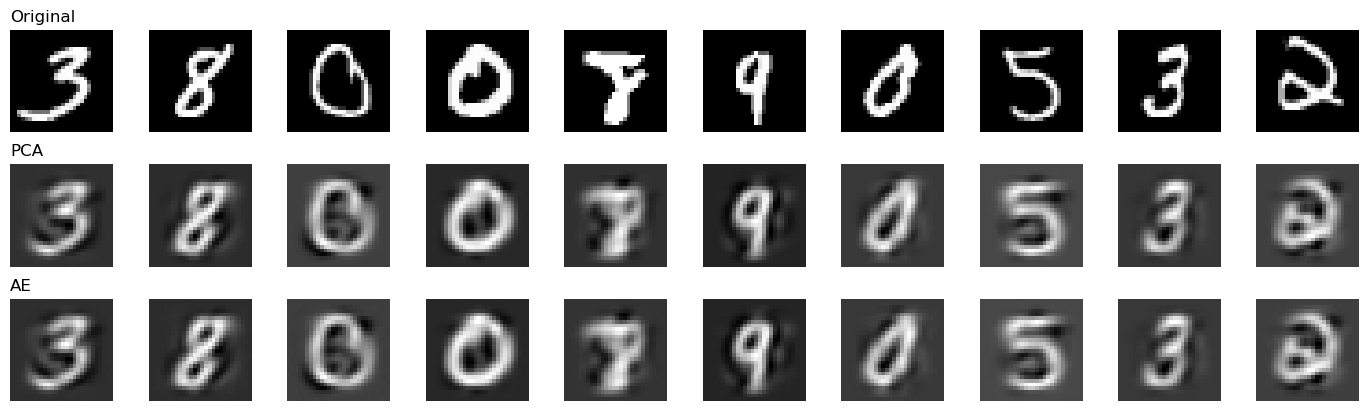

In [50]:
def show_recons(ae_model, pca_model, X_test_np, n=10):
    idx = np.random.choice(len(X_test_np), size=n, replace=False)
    X = torch.tensor(X_test_np[idx]).float().view(n, -1).to(device)
    ae_model.eval()
    with torch.no_grad():
        X_ae = ae_model(X).cpu().numpy()
    X_np = X.cpu().numpy()
    X_pca = pca_model.inverse_transform(pca_model.transform(X_np))
    fig, axes = plt.subplots(3, n, figsize=(1.4*n, 4.2))
    for i in range(n):
        axes[0, i].imshow(X_np[i].reshape(28, 28), cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(X_pca[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
        axes[2, i].imshow(X_ae[i].reshape(28, 28), cmap="gray"); axes[2, i].axis("off")

    axes[0, 0].set_title("Original", fontsize=12, loc='left')
    axes[1, 0].set_title("PCA", fontsize=12, loc='left')
    axes[2, 0].set_title("AE", fontsize=12, loc='left')
    plt.tight_layout()
    plt.show()
    
show_recons(linear_ae, pca, X_test, n=10)

# Non Linear AE

In [54]:
class SimpleNonLinearAE(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int, activation: nn.Module | None = None) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, latent_dim),
            activation if activation is not None else nn.ReLU(),
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, input_dim),
            nn.Sigmoid(),  #!! pixels should be in [0,1]
        )
    
    def forward(self, x):
        return self.decoder(self.encoder(x))

In [ ]:
nonlinear_ae = SimpleNonLinearAE(input_dim=input_dim, latent_dim=latent_dim).to(device)
opt = torch.optim.Adam(nonlinear_ae.parameters(), lr=lr)
crit = nn.MSELoss()       
train_ae_mse(nonlinear_ae, crit, opt, train_dl_raw, test_dl_raw, epochs=30)

epoch 01 | AE test MSE: 0.048070
epoch 02 | AE test MSE: 0.035600
epoch 03 | AE test MSE: 0.028485
epoch 04 | AE test MSE: 0.024814
epoch 05 | AE test MSE: 0.022422
epoch 06 | AE test MSE: 0.020682
epoch 07 | AE test MSE: 0.019381
epoch 08 | AE test MSE: 0.018435
epoch 09 | AE test MSE: 0.017782
epoch 10 | AE test MSE: 0.017262
epoch 11 | AE test MSE: 0.016869
epoch 12 | AE test MSE: 0.016640
epoch 13 | AE test MSE: 0.016441
epoch 14 | AE test MSE: 0.016294
epoch 15 | AE test MSE: 0.016182
epoch 16 | AE test MSE: 0.016149
epoch 17 | AE test MSE: 0.016050
epoch 18 | AE test MSE: 0.016016
epoch 19 | AE test MSE: 0.015939
epoch 20 | AE test MSE: 0.015926
epoch 21 | AE test MSE: 0.015904
epoch 22 | AE test MSE: 0.015854
epoch 23 | AE test MSE: 0.015843
epoch 24 | AE test MSE: 0.015823
epoch 25 | AE test MSE: 0.015811
epoch 26 | AE test MSE: 0.015783
epoch 27 | AE test MSE: 0.015764
epoch 28 | AE test MSE: 0.015768
epoch 29 | AE test MSE: 0.015744
epoch 30 | AE test MSE: 0.015738


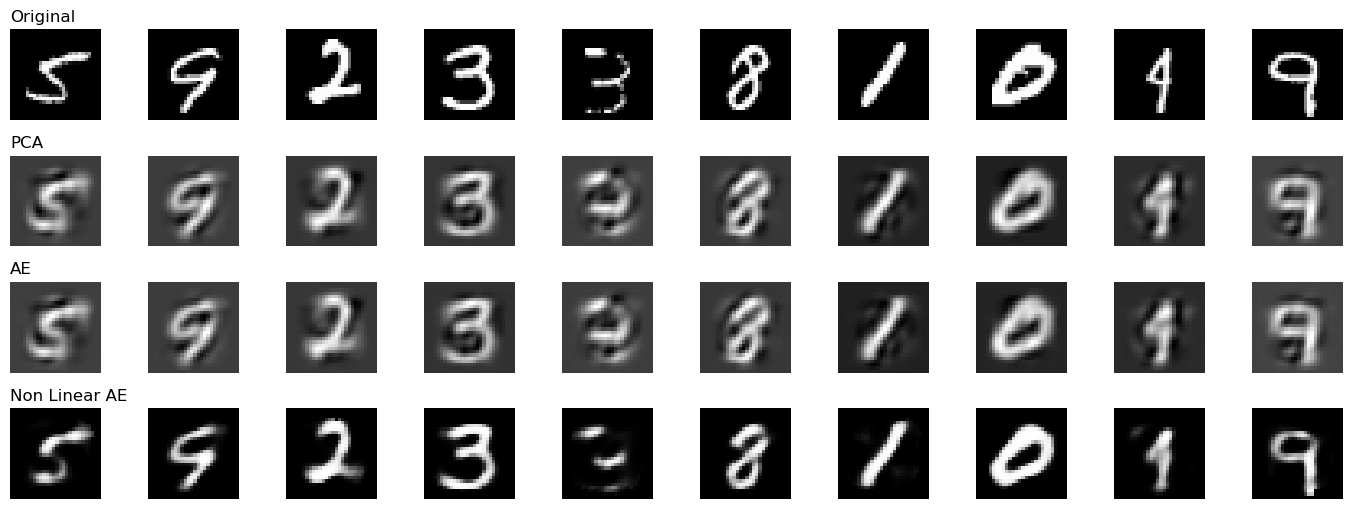

In [53]:
def show_recons(ae_model, nonlinear_ae_model, pca_model, X_test_np, n=10):
    idx = np.random.choice(len(X_test_np), size=n, replace=False)
    X = torch.tensor(X_test_np[idx]).float().view(n, -1).to(device)
    ae_model.eval()
    with torch.no_grad():
        X_ae = ae_model(X).cpu().numpy()
        
    nonlinear_ae_model.eval()
    with torch.no_grad():
        X_non_ae = nonlinear_ae_model(X).cpu().numpy()
    
    X_np = X.cpu().numpy()
    X_pca = pca_model.inverse_transform(pca_model.transform(X_np))
    fig, axes = plt.subplots(4, n, figsize=(1.4*n, 5.2))
    for i in range(n):
        axes[0, i].imshow(X_np[i].reshape(28, 28), cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(X_pca[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
        axes[2, i].imshow(X_ae[i].reshape(28, 28), cmap="gray"); axes[2, i].axis("off")
        axes[3, i].imshow(X_non_ae[i].reshape(28, 28), cmap="gray"); axes[3, i].axis("off")

    axes[0, 0].set_title("Original", fontsize=12, loc='left')
    axes[1, 0].set_title("PCA", fontsize=12, loc='left')
    axes[2, 0].set_title("AE", fontsize=12, loc='left')
    axes[3, 0].set_title("Non Linear AE", fontsize=12, loc='left')
    plt.tight_layout()
    plt.show()
    
show_recons(linear_ae, nonlinear_ae, pca, X_test, n=10)

# Stacked AE

In [57]:
class StackedAE(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int, hidden_dim: int = 100) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SELU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.SELU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.SELU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),  #!! pixels should be in [0,1]
        )
    
    def forward(self, x):
        return self.decoder(self.encoder(x))

In [58]:
stacked_ae = StackedAE(input_dim=input_dim, latent_dim=latent_dim).to(device)
opt = torch.optim.Adam(stacked_ae.parameters(), lr=lr)
crit = nn.MSELoss()       
train_ae_mse(stacked_ae, crit, opt, train_dl_raw, test_dl_raw, epochs=30)

epoch 01 | AE test MSE: 0.037223
epoch 02 | AE test MSE: 0.025787
epoch 03 | AE test MSE: 0.021181
epoch 04 | AE test MSE: 0.019061
epoch 05 | AE test MSE: 0.017866
epoch 06 | AE test MSE: 0.016809
epoch 07 | AE test MSE: 0.015810
epoch 08 | AE test MSE: 0.014815
epoch 09 | AE test MSE: 0.014085
epoch 10 | AE test MSE: 0.013469
epoch 11 | AE test MSE: 0.013026
epoch 12 | AE test MSE: 0.012707
epoch 13 | AE test MSE: 0.012458
epoch 14 | AE test MSE: 0.012193
epoch 15 | AE test MSE: 0.011882
epoch 16 | AE test MSE: 0.011672
epoch 17 | AE test MSE: 0.011484
epoch 18 | AE test MSE: 0.011279
epoch 19 | AE test MSE: 0.011099
epoch 20 | AE test MSE: 0.010994
epoch 21 | AE test MSE: 0.010825
epoch 22 | AE test MSE: 0.010681
epoch 23 | AE test MSE: 0.010556
epoch 24 | AE test MSE: 0.010326
epoch 25 | AE test MSE: 0.010196
epoch 26 | AE test MSE: 0.009961
epoch 27 | AE test MSE: 0.009751
epoch 28 | AE test MSE: 0.009654
epoch 29 | AE test MSE: 0.009487
epoch 30 | AE test MSE: 0.009385


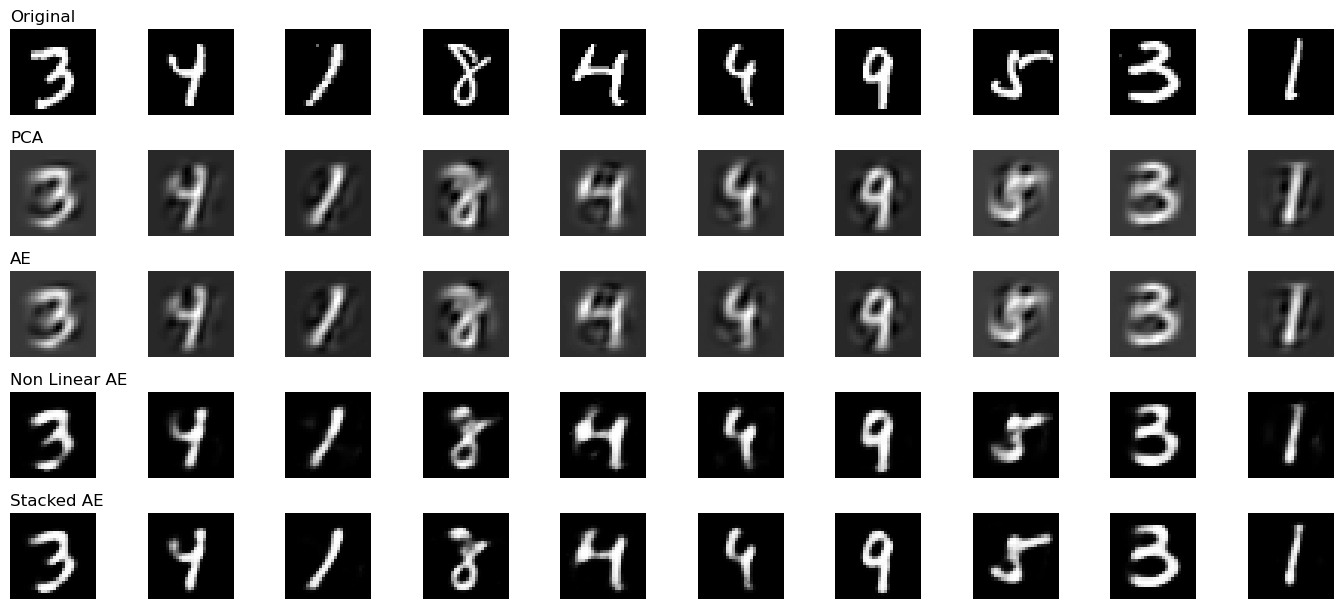

In [63]:
def show_recons(ae_model, nonlinear_ae_model, stacked_ae_model, pca_model, X_test_np, n=10):
    idx = np.random.choice(len(X_test_np), size=n, replace=False)
    X = torch.tensor(X_test_np[idx]).float().view(n, -1).to(device)
    ae_model.eval()
    with torch.no_grad():
        X_ae = ae_model(X).cpu().numpy()
        
    nonlinear_ae_model.eval()
    with torch.no_grad():
        X_non_ae = nonlinear_ae_model(X).cpu().numpy()
        
    stacked_ae_model.eval()
    with torch.no_grad():
        X_stacked_ae = stacked_ae_model(X).cpu().numpy()
    
    X_np = X.cpu().numpy()
    X_pca = pca_model.inverse_transform(pca_model.transform(X_np))
    fig, axes = plt.subplots(5, n, figsize=(1.4*n, 6.2))
    for i in range(n):
        axes[0, i].imshow(X_np[i].reshape(28, 28), cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(X_pca[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
        axes[2, i].imshow(X_ae[i].reshape(28, 28), cmap="gray"); axes[2, i].axis("off")
        axes[3, i].imshow(X_non_ae[i].reshape(28, 28), cmap="gray"); axes[3, i].axis("off")
        axes[4, i].imshow(X_stacked_ae[i].reshape(28, 28), cmap="gray"); axes[4, i].axis("off")

    axes[0, 0].set_title("Original", fontsize=12, loc='left')
    axes[1, 0].set_title("PCA", fontsize=12, loc='left')
    axes[2, 0].set_title("AE", fontsize=12, loc='left')
    axes[3, 0].set_title("Non Linear AE", fontsize=12, loc='left')
    axes[4, 0].set_title("Stacked AE", fontsize=12, loc='left')
    plt.tight_layout()
    plt.show()
    
show_recons(linear_ae, nonlinear_ae, stacked_ae, pca, X_test, n=10)

# Latent Dimension vs Overfitting

keep increasing Latent Dimension tell see when it stop and start overfit

In [ ]:
latent_dims = [16, 32, 64, 128, 256, 512, 600]
losses = []
for latent_dim in latent_dims:
    stacked_ae = StackedAE(input_dim=input_dim, latent_dim=latent_dim).to(device)
    opt = torch.optim.Adam(stacked_ae.parameters(), lr=lr)
    crit = nn.MSELoss()       
    loss = train_ae_mse(stacked_ae, crit, opt, train_dl_raw, test_dl_raw, epochs=10)
    losses.append(loss)

epoch 01 | AE test MSE: 0.037326
epoch 02 | AE test MSE: 0.028909
epoch 03 | AE test MSE: 0.026031
epoch 04 | AE test MSE: 0.024557
epoch 05 | AE test MSE: 0.023504
epoch 06 | AE test MSE: 0.022776
epoch 07 | AE test MSE: 0.022136
epoch 08 | AE test MSE: 0.021378
epoch 09 | AE test MSE: 0.020485
epoch 10 | AE test MSE: 0.019639
epoch 01 | AE test MSE: 0.035959
epoch 02 | AE test MSE: 0.028296
epoch 03 | AE test MSE: 0.022700
epoch 04 | AE test MSE: 0.020394
epoch 05 | AE test MSE: 0.018753
epoch 06 | AE test MSE: 0.017533
epoch 07 | AE test MSE: 0.016605
epoch 08 | AE test MSE: 0.015627
epoch 09 | AE test MSE: 0.014680
epoch 10 | AE test MSE: 0.013644
epoch 01 | AE test MSE: 0.035001
epoch 02 | AE test MSE: 0.024777
epoch 03 | AE test MSE: 0.019617
epoch 04 | AE test MSE: 0.016265
epoch 05 | AE test MSE: 0.014179
epoch 06 | AE test MSE: 0.012958
epoch 07 | AE test MSE: 0.011904
epoch 08 | AE test MSE: 0.010865
epoch 09 | AE test MSE: 0.010158
epoch 10 | AE test MSE: 0.009686
epoch 01 |

In [71]:
latent_dims += [700]
for latent_dim in [700]:
    stacked_ae = StackedAE(input_dim=input_dim, latent_dim=latent_dim).to(device)
    opt = torch.optim.Adam(stacked_ae.parameters(), lr=lr)
    crit = nn.MSELoss()       
    loss = train_ae_mse(stacked_ae, crit, opt, train_dl_raw, test_dl_raw, epochs=10)
    losses.append(loss)

epoch 01 | AE test MSE: 0.023876
epoch 02 | AE test MSE: 0.014743
epoch 03 | AE test MSE: 0.011514
epoch 04 | AE test MSE: 0.009667
epoch 05 | AE test MSE: 0.008432
epoch 06 | AE test MSE: 0.007529
epoch 07 | AE test MSE: 0.006778
epoch 08 | AE test MSE: 0.006252
epoch 09 | AE test MSE: 0.005815
epoch 10 | AE test MSE: 0.005487


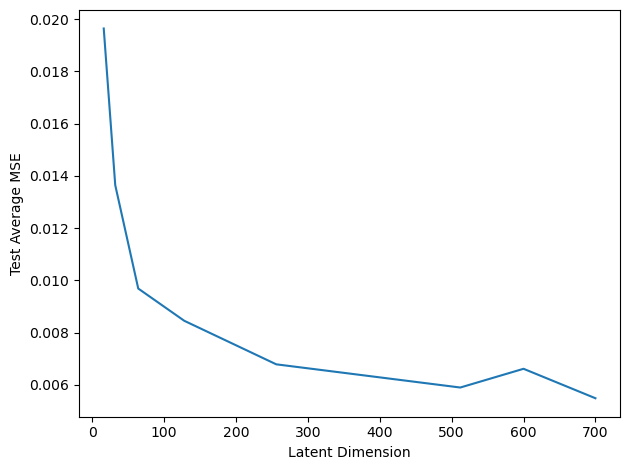

In [ ]:
plt.plot(latent_dims, losses)
plt.xlabel("Latent Dimension")
plt.ylabel("Test Average MSE on 10 Epochs")

plt.tight_layout()
plt.show()

it basically become identity as I can ignore white border pixels 

# CIFAR 10

let's try it on harder dataset

In [76]:
from torchvision.datasets import CIFAR10
from torchvision import transforms

tfm = transforms.ToTensor()  # -> float in [0,1], shape (C,H,W)
cifar_train = CIFAR10(root="./data", train=True, download=True, transform=tfm)
cifar_test = CIFAR10(root="./data", train=False, download=True, transform=tfm)

100%|██████████| 170M/170M [02:02<00:00, 1.39MB/s] 


In [ ]:
cifar

In [ ]:
X = minst['data'].values # (70000, 784)
# normalize it very important
X = (X - X.min()) / X.max()
y = np.array(minst['target'].values) # (70000, )